In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                            precision_score, recall_score, f1_score, roc_curve, auc,
                            roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("imported")

imported


In [3]:
file_path = '/content/drive/MyDrive/ML&&AI/Lab 2/datasets/insurance.csv'

print("="*80)
print("LOADING DATASET FROM GOOGLE DRIVE")
print("="*80)
df = pd.read_csv(file_path)
print(df.head())
print(f"Dataset loaded successfully!")
print(f"File path: {file_path}\n")

LOADING DATASET FROM GOOGLE DRIVE
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dataset loaded successfully!
File path: /content/drive/MyDrive/ML&&AI/Lab 2/datasets/insurance.csv



In [4]:
print("BASIC DATASET INFORMATION")

# Dataset shape
print(f"\nDataset Shape: {df.shape}")
print(f"   - Number of rows (samples): {df.shape[0]}")
print(f"   - Number of columns (features): {df.shape[1]}\n")

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n")

# Display last few rows
print("\nLast 5 rows of the dataset:")
print(df.tail())
print("\n")

# Column names and types
print("\nCOLUMN INFORMATION")
print(f"\n📋 Column Names: {list(df.columns)}\n")
print("Data Types:")
print(df.dtypes)
print("\n")

# Detailed information
print("\nDETAILED DATASET INFO")
df.info()
print("\n")

BASIC DATASET INFORMATION

Dataset Shape: (1338, 7)
   - Number of rows (samples): 1338
   - Number of columns (features): 7

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520



Last 5 rows of the dataset:
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603



COLUMN INFORMATION

📋 Column Names: [

In [5]:
print("\nMISSING DATA ANALYSIS")

# Count missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create detailed missing data report with data types
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Missing Count': [df[col].isnull().sum() for col in df.columns],
    'Missing Percentage': [(df[col].isnull().sum() / len(df)) * 100 for col in df.columns]
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False
).reset_index(drop=True)

print("\nCOLUMN DATA TYPES:")
print(df.dtypes)

if len(missing_df) > 0:
    print("\nMISSING VALUES DETECTED:")
    print(missing_df.to_string())

    # Visualize missing data
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.bar(missing_df['Column'], missing_df['Missing Count'], color='coral', edgecolor='black')
    plt.title('Missing Values Count by Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    plt.subplot(1, 2, 2)
    plt.bar(missing_df['Column'], missing_df['Missing Percentage'], color='lightblue', edgecolor='black')
    plt.title('Missing Values Percentage by Column')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")


MISSING DATA ANALYSIS

COLUMN DATA TYPES:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

✓ No missing values found in the dataset!


In [6]:
print("\nCATEGORICAL DATA TYPE CONVERSION (Object to Integer)")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"\nCategorical columns found: {categorical_cols}")
    from sklearn.preprocessing import LabelEncoder

    label_encoders = {}
    df_encoded = df.copy()

    for col in categorical_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col])
        label_encoders[col] = le

        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"\n  {col}:")
        for orig_val, encoded_val in mapping.items():
            print(f"    '{orig_val}' → {encoded_val}")

    print(f"\nAll converted! Data types after encoding:")
    print(df_encoded.dtypes)
    df = df_encoded
else:
    print("\nNo categorical columns found!")


CATEGORICAL DATA TYPE CONVERSION (Object to Integer)

Categorical columns found: ['sex', 'smoker', 'region']

  sex:
    'female' → 0
    'male' → 1

  smoker:
    'no' → 0
    'yes' → 1

  region:
    'northeast' → 0
    'northwest' → 1
    'southeast' → 2
    'southwest' → 3

All converted! Data types after encoding:
age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object


In [7]:
print("\nDUPLICATE DATA ANALYSIS")

duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"{duplicate_count} duplicate rows found!")
    print("Duplicate rows:")
    print(df[df.duplicated(keep=False)])

    # Remove duplicates
    df = df.drop_duplicates()
    print(f"\nDuplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found!")



DUPLICATE DATA ANALYSIS

Number of duplicate rows: 1
1 duplicate rows found!
Duplicate rows:
     age  sex    bmi  children  smoker  region    charges
195   19    1  30.59         0       0       1  1639.5631
581   19    1  30.59         0       0       1  1639.5631

Duplicates removed. New shape: (1337, 7)



CORRELATION ANALYSIS

Correlation Matrix:
               age       sex       bmi  children    smoker    region   charges
age       1.000000 -0.019814  0.109344  0.041536 -0.025587  0.001626  0.298308
sex      -0.019814  1.000000  0.046397  0.017848  0.076596  0.004936  0.058044
bmi       0.109344  0.046397  1.000000  0.012755  0.003746  0.157574  0.198401
children  0.041536  0.017848  0.012755  1.000000  0.007331  0.016258  0.067389
smoker   -0.025587  0.076596  0.003746  0.007331  1.000000 -0.002358  0.787234
region    0.001626  0.004936  0.157574  0.016258 -0.002358  1.000000 -0.006547
charges   0.298308  0.058044  0.198401  0.067389  0.787234 -0.006547  1.000000


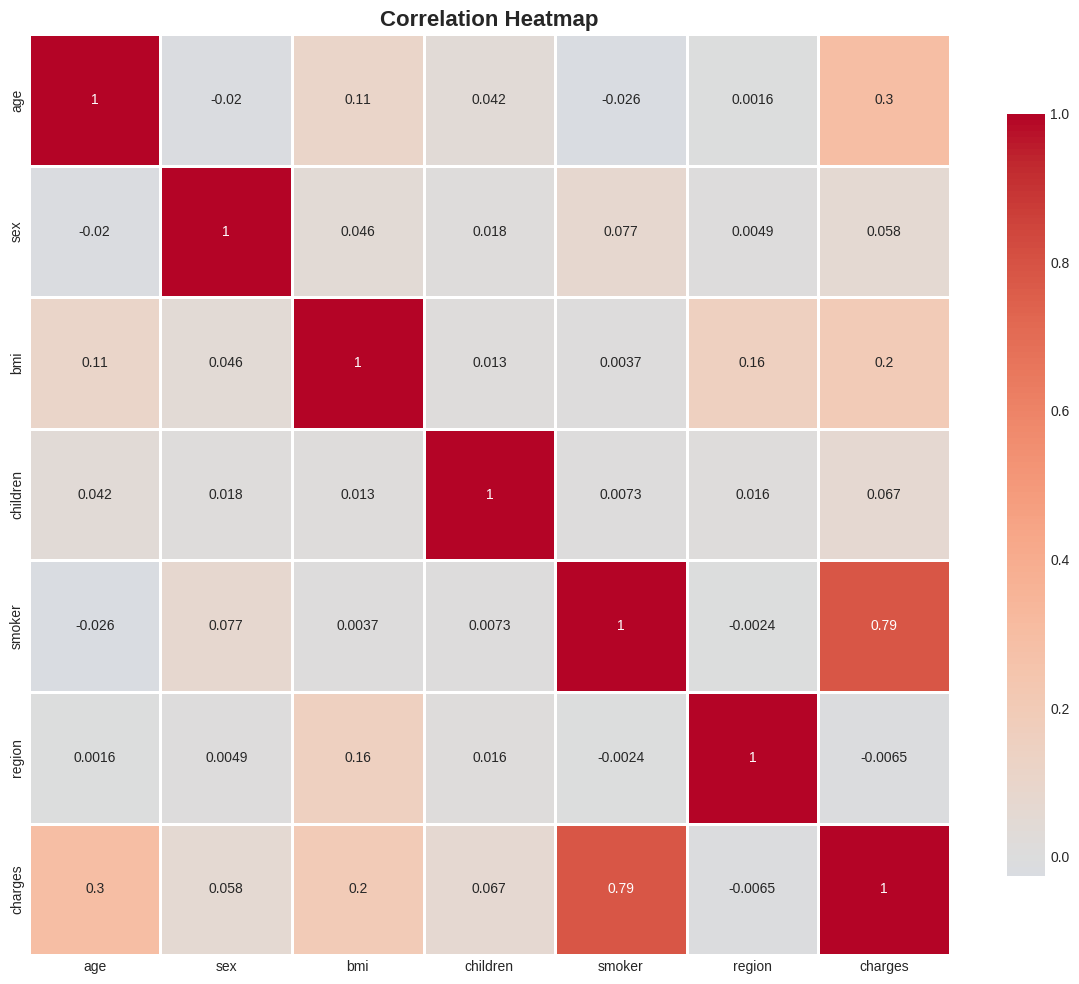


Highly Correlated Feature Pairs (|correlation| > 0.7):
  smoker <-> charges: 0.787


In [8]:
print("\nCORRELATION ANALYSIS")

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numerical_cols) > 1:
    # Correlation matrix
    correlation_matrix = df[numerical_cols].corr()

    print("\nCorrelation Matrix:")
    print(correlation_matrix)

    # Visualize correlation matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Find highly correlated features
    print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr_pairs.append((
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation_matrix.iloc[i, j]
                ))

    if high_corr_pairs:
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} <-> {feat2}: {corr:.3f}")
    else:
        print("  No highly correlated pairs found.")


In [19]:

print("FEATURE SELECTION & BINARY TARGET VARIABLE")


# Identify the target variable (assuming 'charges' is the target)
target_col = 'charges'

if target_col in df.columns:
    print(f"\nTarget variable identified: '{target_col}'")

    # Calculate median for binary classification
    median_charges = df[target_col].median()
    print(f"\nConverting '{target_col}' to Binary Classification:")
    print(f"   Median Charges: ${median_charges:.2f}")
    print(f"   Class 0 (Low Charges): < ${median_charges:.2f}")
    print(f"   Class 1 (High Charges): >= ${median_charges:.2f}")

    # Create binary target
    y_binary = (df[target_col] >= median_charges).astype(int)

    print(f"\nBinary target created:")
    print(f"   Class 0 (Low):  {(y_binary == 0).sum()} samples ({(y_binary == 0).sum() / len(y_binary) * 100:.1f}%)")
    print(f"   Class 1 (High): {(y_binary == 1).sum()} samples ({(y_binary == 1).sum() / len(y_binary) * 100:.1f}%)")

    X = df.drop(columns=[target_col])
    y = y_binary

    print(f"\nFeatures (X):")
    print(f"  Columns: {list(X.columns)}")
    print(f"  Shape: {X.shape}")
    print(f"  Data types:\n{X.dtypes}\n")

    print(f"Target (y):")
    print(f"  Shape: {y.shape}")
    print(f"  Classes: {sorted(y.unique())}")
    print(f"  Class Distribution:\n{y.value_counts().sort_index()}")
else:
    print(f"Target variable '{target_col}' not found in columns!")
    print(f"Available columns: {list(df.columns)}")


FEATURE SELECTION & BINARY TARGET VARIABLE

Target variable identified: 'charges'

Converting 'charges' to Binary Classification:
   Median Charges: $9386.16
   Class 0 (Low Charges): < $9386.16
   Class 1 (High Charges): >= $9386.16

Binary target created:
   Class 0 (Low):  668 samples (50.0%)
   Class 1 (High): 669 samples (50.0%)

Features (X):
  Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
  Shape: (1337, 6)
  Data types:
age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
dtype: object

Target (y):
  Shape: (1337,)
  Classes: [np.int64(0), np.int64(1)]
  Class Distribution:
charges
0    668
1    669
Name: count, dtype: int64


In [20]:

print("TRAIN-TEST SPLIT")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining Set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Class 0 (Low Charges):  {(y_train == 0).sum()} samples")
print(f"  Class 1 (High Charges): {(y_train == 1).sum()} samples")

print(f"\nTest Set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Class 0 (Low Charges):  {(y_test == 0).sum()} samples")
print(f"  Class 1 (High Charges): {(y_test == 1).sum()} samples")

print(f"\nSplit Ratio:")
print(f"  Training: {X_train.shape[0] / len(X) * 100:.1f}%")
print(f"  Testing: {X_test.shape[0] / len(X) * 100:.1f}%")


TRAIN-TEST SPLIT

Training Set:
  X_train shape: (1069, 6)
  y_train shape: (1069,)
  Class 0 (Low Charges):  536 samples
  Class 1 (High Charges): 533 samples

Test Set:
  X_test shape: (268, 6)
  y_test shape: (268,)
  Class 0 (Low Charges):  132 samples
  Class 1 (High Charges): 136 samples

Split Ratio:
  Training: 80.0%
  Testing: 20.0%


In [21]:

print("DATA NORMALIZATION/SCALING")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStandardScaler applied to features")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled shape: {X_test_scaled.shape}")

print("\nScaled Data Statistics (Training Set):")
print(f"  Mean: {X_train_scaled.mean(axis=0)}")
print(f"  Std Dev: {X_train_scaled.std(axis=0)}")


DATA NORMALIZATION/SCALING

StandardScaler applied to features
  X_train_scaled shape: (1069, 6)
  X_test_scaled shape: (268, 6)

Scaled Data Statistics (Training Set):
  Mean: [1.67831656e-16 4.15424892e-17 1.66169957e-17 5.06818369e-17
 3.48956910e-17 6.64679828e-17]
  Std Dev: [1. 1. 1. 1. 1. 1.]


In [22]:

print("LOGISTIC REGRESSION MODEL TRAINING")

# Create and train the logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
model.fit(X_train_scaled, y_train)

print("\nLogistic Regression Model Trained Successfully!")

print(f"\nModel Coefficients (Feature Weights):")
for i, feature in enumerate(X.columns):
    print(f"  {feature:15s}: {model.coef_[0][i]:10.4f}")

print(f"\nModel Intercept (Bias): {model.intercept_[0]:.4f}")

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_train_proba = model.predict_proba(X_train_scaled)[:, 1]

y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"\nPredictions and probabilities generated for both training and test sets")



LOGISTIC REGRESSION MODEL TRAINING

Logistic Regression Model Trained Successfully!

Model Coefficients (Feature Weights):
  age            :     2.1789
  sex            :    -0.1402
  bmi            :     0.0771
  children       :     0.1370
  smoker         :     3.2068
  region         :    -0.2090

Model Intercept (Bias): 0.5327

Predictions and probabilities generated for both training and test sets


In [25]:

print("CLASSIFICATION METRICS")


# Calculate evaluation metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_proba)

# Calculate evaluation metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print("\nTRAINING SET METRICS:")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")
print(f"  AUC-ROC:   {train_auc:.4f}")

print("\nTEST SET METRICS:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  AUC-ROC:   {test_auc:.4f}")

# Confusion matrices
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

print("\nCONFUSION MATRIX (Training Set):")
print(f"  True Negatives:  {train_cm[0, 0]:5d}  |  False Positives: {train_cm[0, 1]:5d}")
print(f"  False Negatives: {train_cm[1, 0]:5d}  |  True Positives:  {train_cm[1, 1]:5d}")

print("\nCONFUSION MATRIX (Test Set):")
print(f"  True Negatives:  {test_cm[0, 0]:5d}  |  False Positives: {test_cm[0, 1]:5d}")
print(f"  False Negatives: {test_cm[1, 0]:5d}  |  True Positives:  {test_cm[1, 1]:5d}")

print("\nMODEL ANALYSIS:")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Test Accuracy:     {test_accuracy:.4f}")
print(f"  Difference:        {abs(train_accuracy - test_accuracy):.4f}")

if train_accuracy - test_accuracy > 0.1:
    print("Possible overfitting detected!")
else:
    print("\nModel generalizes well!")


CLASSIFICATION METRICS

TRAINING SET METRICS:
  Accuracy:  0.9083
  Precision: 0.9112
  Recall:    0.9043
  F1-Score:  0.9077
  AUC-ROC:   0.9449

TEST SET METRICS:
  Accuracy:  0.9030
  Precision: 0.8819
  Recall:    0.9338
  F1-Score:  0.9071
  AUC-ROC:   0.9669

CONFUSION MATRIX (Training Set):
  True Negatives:    489  |  False Positives:    47
  False Negatives:    51  |  True Positives:    482

CONFUSION MATRIX (Test Set):
  True Negatives:    115  |  False Positives:    17
  False Negatives:     9  |  True Positives:    127

MODEL ANALYSIS:
  Training Accuracy: 0.9083
  Test Accuracy:     0.9030
  Difference:        0.0053

Model generalizes well!


CONFUSION MATRIX & METRICS VISUALIZATION


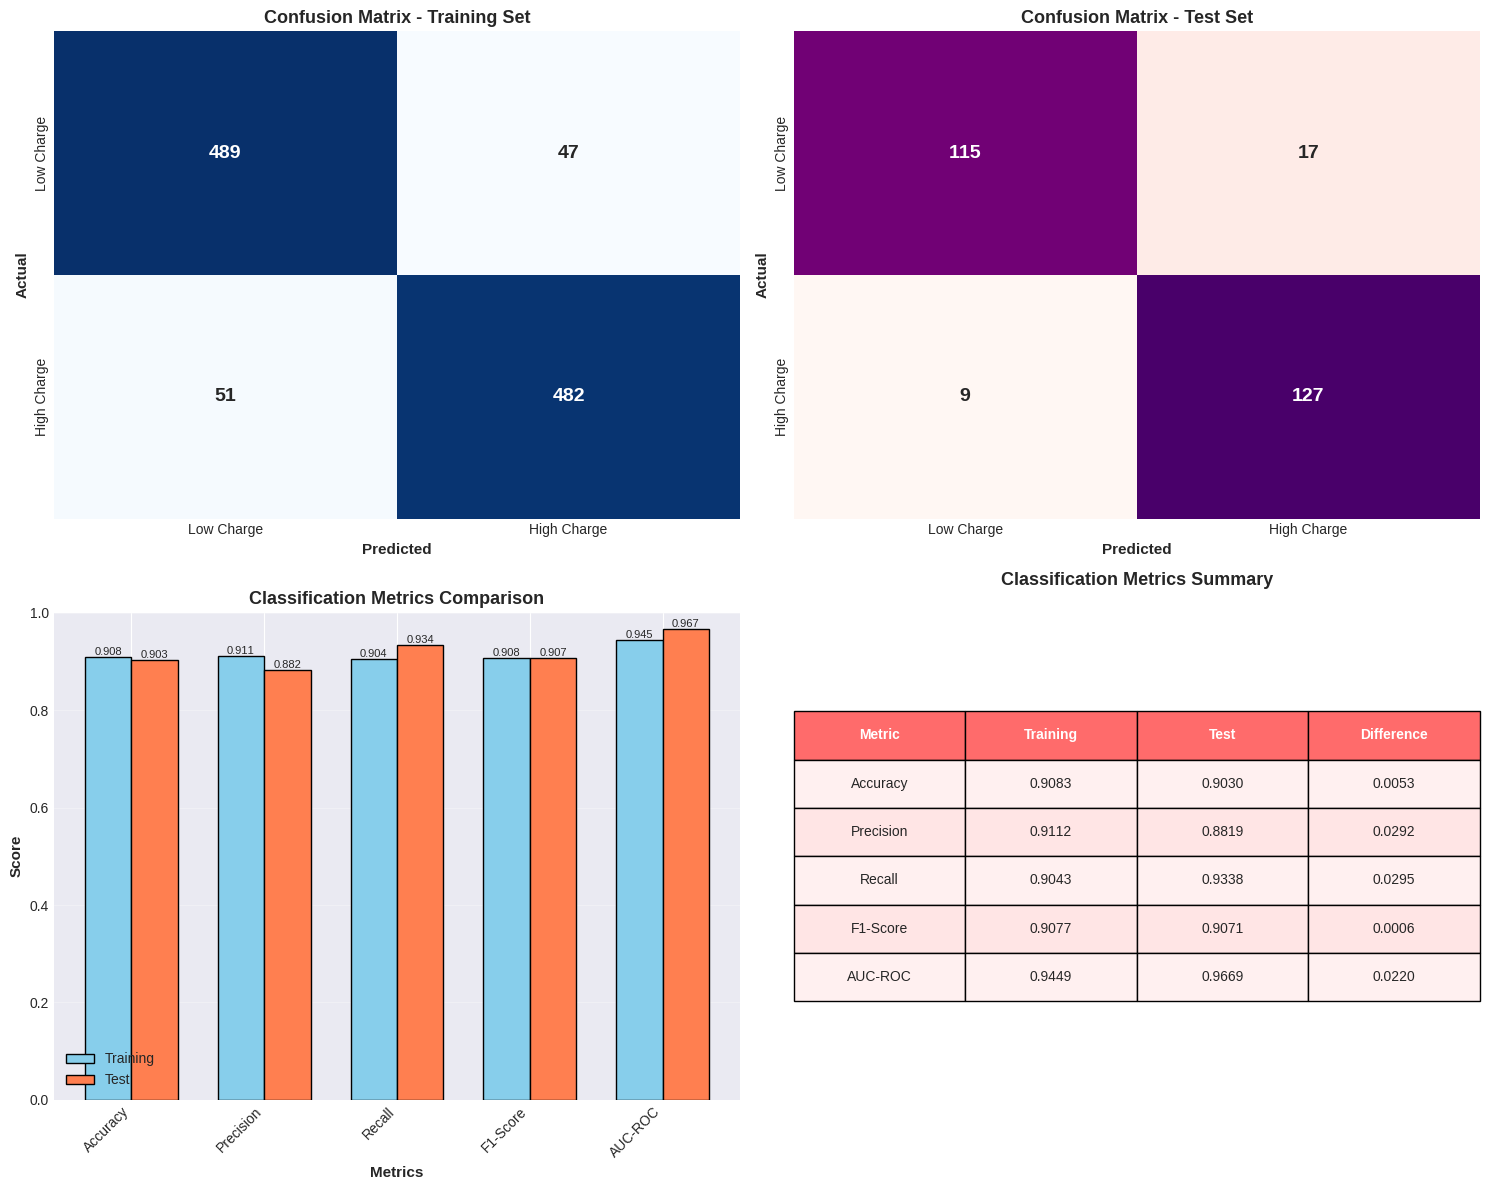


Classification visualization complete!


In [27]:

print("CONFUSION MATRIX & METRICS VISUALIZATION")


# Create comprehensive classification visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix Heatmap (Training)
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0],
            xticklabels=['Low Charge', 'High Charge'],
            yticklabels=['Low Charge', 'High Charge'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0, 0].set_title('Confusion Matrix - Training Set', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Actual', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Predicted', fontsize=11, fontweight='bold')

# 2. Confusion Matrix Heatmap (Test)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='RdPu', cbar=False, ax=axes[0, 1],
            xticklabels=['Low Charge', 'High Charge'],
            yticklabels=['Low Charge', 'High Charge'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0, 1].set_title('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Actual', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontsize=11, fontweight='bold')

# 3. Classification Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
train_scores = [train_accuracy, train_precision, train_recall, train_f1, train_auc]
test_scores = [test_accuracy, test_precision, test_recall, test_f1, test_auc]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1, 0].bar(x - width/2, train_scores, width, label='Training', color='skyblue', edgecolor='black')
bars2 = axes[1, 0].bar(x + width/2, test_scores, width, label='Test', color='coral', edgecolor='black')

axes[1, 0].set_xlabel('Metrics', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Classification Metrics Comparison', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 4. Metrics Summary Table
axes[1, 1].axis('off')

summary_data = [
    ['Metric', 'Training', 'Test', 'Difference'],
    ['Accuracy', f'{train_accuracy:.4f}', f'{test_accuracy:.4f}', f'{abs(train_accuracy - test_accuracy):.4f}'],
    ['Precision', f'{train_precision:.4f}', f'{test_precision:.4f}', f'{abs(train_precision - test_precision):.4f}'],
    ['Recall', f'{train_recall:.4f}', f'{test_recall:.4f}', f'{abs(train_recall - test_recall):.4f}'],
    ['F1-Score', f'{train_f1:.4f}', f'{test_f1:.4f}', f'{abs(train_f1 - test_f1):.4f}'],
    ['AUC-ROC', f'{train_auc:.4f}', f'{test_auc:.4f}', f'{abs(train_auc - test_auc):.4f}']
]

table = axes[1, 1].table(cellText=summary_data, cellLoc='center', loc='center',
                         colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#FF6B6B')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, 6):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#FFE5E5')
        else:
            table[(i, j)].set_facecolor('#FFF0F0')

axes[1, 1].set_title('Classification Metrics Summary', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nClassification visualization complete!")

ROC CURVE VISUALIZATION


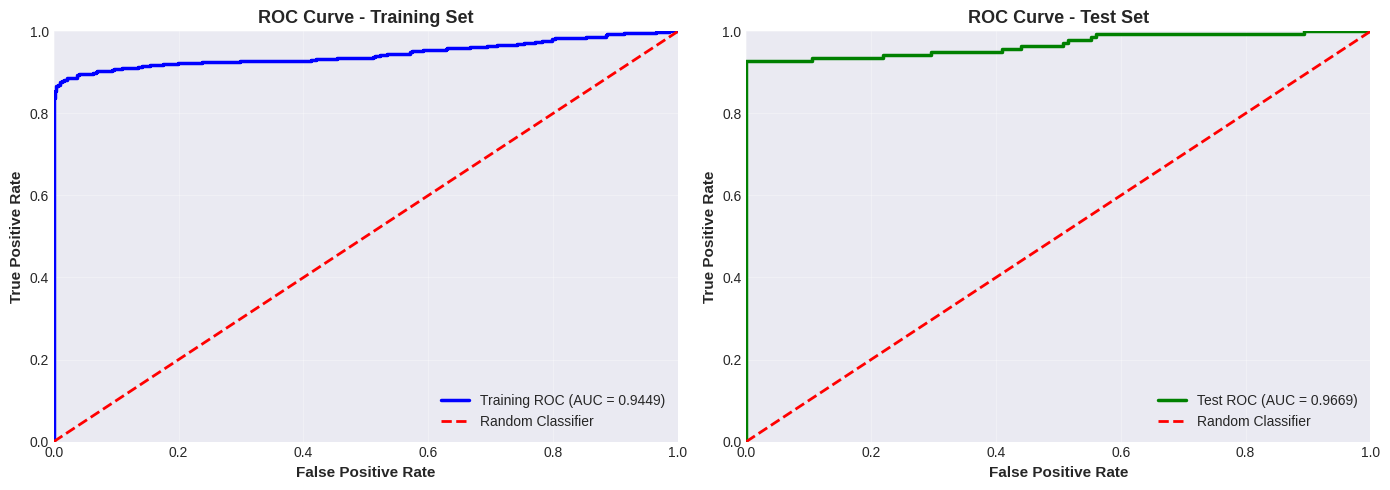


ROC Curve visualization complete!

  Training AUC: 0.9449
  Test AUC: 0.9669


In [29]:
print("ROC CURVE VISUALIZATION")

# Calculate ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

# Create ROC curve visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training ROC Curve
axes[0].plot(fpr_train, tpr_train, color='blue', lw=2.5, label=f'Training ROC (AUC = {train_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve - Training Set', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Test ROC Curve
axes[1].plot(fpr_test, tpr_test, color='green', lw=2.5, label=f'Test ROC (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[1].set_title('ROC Curve - Test Set', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nROC Curve visualization complete!")
print(f"\n  Training AUC: {train_auc:.4f}")
print(f"  Test AUC: {test_auc:.4f}")

In [30]:
print("SAMPLE PREDICTIONS WITH PROBABILITY SCORES")


# Display sample predictions on test set
sample_size = min(15, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)
sample_indices = sorted(sample_indices)

print(f"\nSample Predictions (First {sample_size} Test Samples):\n")
print(f"{'Index':<8} {'Actual':<8} {'Predicted':<12} {'Probability':<15} {'Confidence':<12}")
print("-" * 65)

for idx in sample_indices:
    actual = y_test.iloc[idx]
    predicted = y_test_pred[idx]
    probability = y_test_proba[idx]
    confidence = max(probability, 1 - probability) * 100

    actual_label = 'High' if actual == 1 else 'Low'
    predicted_label = 'High' if predicted == 1 else 'Low'

    print(f"{idx:<8} {actual_label:<8} {predicted_label:<12} {probability:.4f}             {confidence:.2f}%")

print("\n" + "="*80)
print("✓ Logistic Regression Classification Complete!")
print("="*80)

SAMPLE PREDICTIONS WITH PROBABILITY SCORES

Sample Predictions (First 15 Test Samples):

Index    Actual   Predicted    Probability     Confidence  
-----------------------------------------------------------------
7        Low      Low          0.0165             98.35%
11       High     High         0.9998             99.98%
28       High     High         0.7072             70.72%
33       High     High         0.8247             82.47%
75       Low      Low          0.0097             99.03%
77       Low      Low          0.1100             89.00%
149      High     High         0.9261             92.61%
182      High     High         0.7033             70.33%
186      Low      Low          0.0240             97.60%
231      High     High         0.9963             99.63%
234      High     High         0.8283             82.83%
246      Low      Low          0.0364             96.36%
255      High     High         0.9722             97.22%
261      High     High         1.0000       